In [1]:
import hanlp

# Pipeline allows blending multiple callable functions no matter they are a rule, a TensorFlow component or a PyTorch
# one. However, it's slower than the MTL framework.
# pos = hanlp.load(hanlp.pretrained.pos.CTB9_POS_ALBERT_BASE)  # In case both tf and torch are used, load tf first.

HanLP = hanlp.pipeline()\
    .append(hanlp.load('CTB9_TOK_ELECTRA_BASE_CRF'), output_key='tok') \
    .append(hanlp.load('CTB9_POS_ELECTRA_SMALL_TF'), output_key='pos') \
    .append(hanlp.load('CTB9_DEP_ELECTRA_SMALL', conll=0), output_key='dep', input_key='tok')

In [2]:
from YSUtils import *
from collections import defaultdict
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

In [3]:
output = []
for txt_file in list_txt_files("./LCMC_all_txt/"):
    lines = []
    with open(txt_file, "r", encoding="utf-8") as file:
        for line in file:
            if line == '\n' or len(line.strip()) > 128:
                continue
            lines.append(line.strip())
    doc = HanLP(lines)
    
    
    for i, line in enumerate(lines):
        line_json = {}
        line_json["text"] = line.strip()
        line_deps_with_word = []
        for j, dep_couple in enumerate(doc["dep"][i]):
            str_with_word =  doc["pos"][i][j] + ' ' + doc["pos"][i][dep_couple[0] - 1] + ' ' + dep_couple[1] + ' ' + doc["tok"][i][j] + ' ' + doc["tok"][i][dep_couple[0] - 1] + ' ' + dep_couple[1]
            # str_dep = doc["pos/ctb"][i][j] + ' ' + doc["pos/ctb"][i][dep_couple[0] - 1] + ' ' + dep_couple[1] + ' ' + doc["tok/coarse"][i][j] + ' ' + doc["tok/coarse"][i][j] + ' ' + dep_couple[1]
            line_deps_with_word.append(str_with_word)
        line_json["deps_with_word"] = line_deps_with_word
        output.append(line_json)
with open("./dep_feature/LCMC_all_dep.json", "w", encoding="utf-8") as file:
    file.write(json.dumps(output, ensure_ascii=False))

    

In [17]:
feature_count = defaultdict(int)
with open('./dep_feature/origin_dep_feature.json', 'r', encoding='utf-8') as file:
    origin_dep_feature = json.load(file)
for line in origin_dep_feature:
    for dep in line["deps_with_word"]:
        dep_list = dep.split()
        dep_feature = dep_list[0] + " " + dep_list[1] + " " + dep_list[2]
        feature_count[dep_feature] += 1

with open('./dep_feature/instruct_dep_feature.json', 'r', encoding='utf-8') as file:
    instruct_dep_feature = json.load(file)
for line in instruct_dep_feature:
    for dep in line["deps_with_word"]:
        dep_list = dep.split()
        # 将前三个元素组成字符串
        dep_feature = dep_list[0] + " " + dep_list[1] + " " + dep_list[2]
        feature_count[dep_feature] += 1

sorted_feature_count = dict(sorted(feature_count.items(), key=lambda x: x[1], reverse=True))
with open('./dep_feature/dep_feature_count.json', 'w', encoding='utf-8') as file:
    file.write(json.dumps(sorted_feature_count, ensure_ascii=False))

In [3]:
with open('./dep_feature/dep_feature_count.json', 'r', encoding='utf-8') as file:
    dep_feature_count = json.load(file)
    # 筛选出大于50的键值对
    dep_feature_index = {k: v for k, v in dep_feature_count.items() if v > 200}
    for index,key in enumerate(dep_feature_index.keys()):
        dep_feature_index[key] = index
    with open('./dep_feature/dep_feature_index.json', 'w', encoding='utf-8') as file:
        file.write(json.dumps(dep_feature_index, ensure_ascii=False))

In [4]:
x = []
y = []
with open('./dep_feature/dep_feature_index.json', 'r', encoding='utf-8') as file:
    dep_feature_index = json.load(file)
with open('./dep_feature/instruct_dep_feature.json', 'r', encoding='utf-8') as file:
    instruct_dep_feature = json.load(file)
    for line in instruct_dep_feature:
        line_vec = np.zeros(len(dep_feature_index))
        for dep in line["deps_with_word"]:
            dep_list = dep.split()
            dep_feature = dep_list[0] + " " + dep_list[1] + " " + dep_list[2]
            if dep_feature in dep_feature_index:
                line_vec[dep_feature_index[dep_feature]] += 1
        x.append(line_vec)
        y.append(1)
with open('./dep_feature/origin_dep_feature.json', 'r', encoding='utf-8') as file:
    origin_dep_feature = json.load(file)
    for line in origin_dep_feature:
        line_vec = np.zeros(len(dep_feature_index))
        for dep in line["deps_with_word"]:
            dep_list = dep.split()
            dep_feature = dep_list[0] + " " + dep_list[1] + " " + dep_list[2]
            if dep_feature in dep_feature_index:
                line_vec[dep_feature_index[dep_feature]] += 1
        x.append(line_vec)
        y.append(0)
x = np.array(x)
y = np.array(y)

with open('./dep_feature/dep_feature_vec.json', 'w', encoding='utf-8') as file:
    file.write(json.dumps(x.tolist(), ensure_ascii=False))
with open('./dep_feature/dep_feature_label.json', 'w', encoding='utf-8') as file:
    file.write(json.dumps(y.tolist(), ensure_ascii=False))


第 1 折准确率: 0.6667
第 2 折准确率: 0.6608
第 3 折准确率: 0.6965
第 4 折准确率: 0.6729
第 5 折准确率: 0.6898
特征重要性排名：
PU VV punct: 0.0413
NN NN nn: 0.0371
PN VV nsubj: 0.0337
AD VV advmod: 0.0322
NN VV dobj: 0.0289
VV VV dep: 0.0267
NR VV nsubj: 0.0258
NN VV nsubj: 0.0243
NR NN nn: 0.0202
VV VV conj: 0.0202
PU NN punct: 0.0198
VV VV mmod: 0.0198
JJ NN amod: 0.0189
DT NN det: 0.0184
CD M nummod: 0.0179
P VV prep: 0.0171
VV VV ccomp: 0.0163
AD VA advmod: 0.0160
AS VV asp: 0.0153
M NN clf: 0.0142
NN P pobj: 0.0136
DEC VV cpm: 0.0133
LC P plmod: 0.0127
VV NN rcmod: 0.0112
NN VC attr: 0.0111
NN NN conj: 0.0109
CD NN nummod: 0.0109
NR NN assmod: 0.0108
CC NN cc: 0.0106
DEG NN assm: 0.0105
PU VC punct: 0.0105
PN NN assmod: 0.0104
NN NN assmod: 0.0103
PU NR punct: 0.0098
NT VV tmod: 0.0097
MSP VV prtmod: 0.0095
NN LC lobj: 0.0094
SB VV pass: 0.0091
AD VV neg: 0.0090
NN VA nsubj: 0.0088
DEC VA cpm: 0.0083
AD VC advmod: 0.0080
SP VV dep: 0.0078
NN VE dobj: 0.0077
DEG PN assm: 0.0077
P VA prep: 0.0076
VA NN rcmod: 0.007

/var/folders/bd/kf4g4tn94klg_v30580ms7x40000gn/T/ipykernel_21662/1469179538.py:42: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bd/kf4g4tn94klg_v30580ms7x40000gn/T/ipykernel_21662/1469179538.py:42: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bd/kf4g4tn94klg_v30580ms7x40000gn/T/ipykernel_21662/1469179538.py:42: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bd/kf4g4tn94klg_v30580ms7x40000gn/T/ipykernel_21662/1469179538.py:42: UserWarning: Glyph 31216 (\N{CJK UNIFIED IDEOGRAPH-79F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bd/kf4g4tn94klg_v30580ms7x40000gn/T/ipykernel_21662/1469179538.py:42: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/bd/kf4g

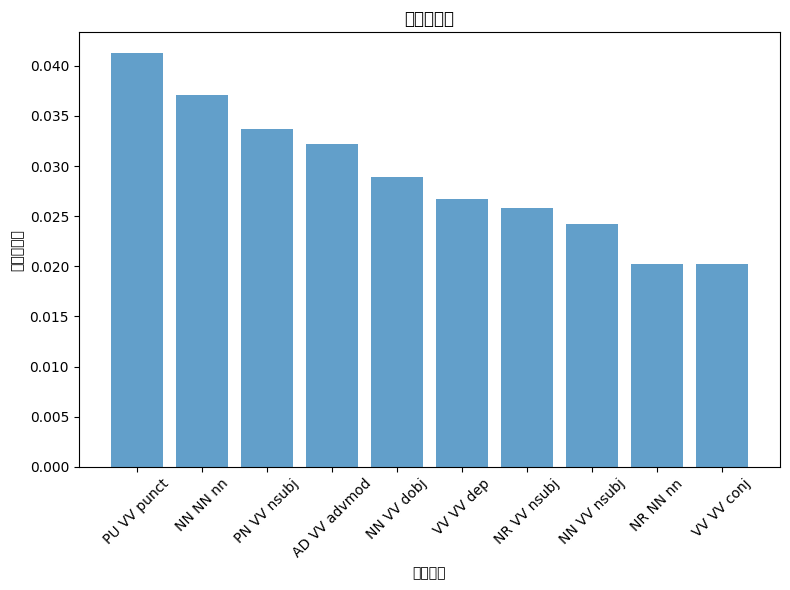

In [10]:
with open('./dep_feature/dep_feature_vec.json', 'r', encoding='utf-8') as file:
    x = json.load(file)
with open('./dep_feature/dep_feature_label.json', 'r', encoding='utf-8') as file:
    y = json.load(file)
x = np.array(x)
y = np.array(y)
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# 创建模型

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42, max_features=109)
for fold, (train_index, test_index) in enumerate(skf.split(x,y)):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]

    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    print(f"第 {fold+1} 折准确率: {score:.4f}")

# 读取字典
with open('./dep_feature/dep_feature_index.json', 'r', encoding='utf-8') as f:
    feature_names = json.load(f)
# 反转字典：交换 key 和 value
feature_names = {v: k for k, v in feature_names.items()}

# 提取特征重要性
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

# 打印特征重要性
print("特征重要性排名：")
for i in indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

# 可视化
plt.figure(figsize=(8, 6))
plt.bar(range(10), importances[indices][:10], align='center', alpha=0.7)
plt.xticks(range(10), [feature_names[i] for i in indices[:10]], rotation=45)
plt.xlabel('特征名称')
plt.ylabel('重要性得分')
plt.title('特征重要性')
plt.tight_layout()
plt.show()